In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_and_prepare_data(filepath):
    df = pd.read_csv(filepath)

    #Clean column names
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '', regex=False)

    df.drop(columns=['Bwd_Avg_Bytes/Bulk', 'Bwd_Avg_Packets/Bulk', 'Fwd_Avg_Bulk_Rate',
                     'Fwd_Avg_Bytes/Bulk', 'Fwd_Avg_Packets/Bulk', 'ECE_Flag_Count',
                     'CWE_Flag_Count', 'RST_Flag_Count', 'FIN_Flag_Count',
                     'Bwd_URG_Flags', 'Fwd_URG_Flags', 'Bwd_PSH_Flags'], inplace=True, errors='ignore')

    #Drop irrelevant columns
    df.drop(columns=['Unnamed:_0', 'Flow_ID', 'Source_IP', 'Destination_IP', 'Timestamp'], inplace=True, errors='ignore')

    #Drop duplicate features
    df = df.loc[:, df.nunique() > 1]

    #Replace inf and drop NaNs
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    #Filter invalid IPs and ports
    df = df[df['Source_Port'].notnull() & df['Destination_Port'].notnull()]
    df = df[df['Source_Port'] != '0']
    df = df[df['Destination_Port'] != '0']

    return df

In [2]:
train_df = load_and_prepare_data('Dataset/train_data.csv')
test_df = load_and_prepare_data('Dataset/test_data.csv')

#Training
if 'Class' in train_df.columns:

    X = train_df.drop(['Class'], axis=1)
    y = train_df['Class']
    
    #Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    #Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    X_train = np.nan_to_num(X_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    #Instantiate models

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train, y_train)
    y_pred_lr = log_reg.predict(X_test)
    
    svm = SVC(kernel='rbf', C=1, gamma='scale', max_iter=1000)
    svm.fit(X_train, y_train)

    #Predict
    y_pred_svm = svm.predict(X_test)

#Testing
if 'Class' not in test_df.columns:
    X_test = test_df.copy()
    X_test_scaled = scaler.transform(X_test)

    #Predict
    preds_lr = log_reg.predict(X_test_scaled)
    preds_rf = rf.predict(X_test_scaled)
    preds_svm = svm.predict(X_test_scaled)

    #Save predictions
    test_df['Pred_LogReg'] = preds_lr
    test_df['Pred_RF'] = preds_rf
    test_df['Pred_SVM'] = preds_svm

    test_df.to_csv('Dataset/test_predictions.csv', index=False)
    print("Predictions saved to test_predictions.csv")


/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Predictions saved to test_predictions.csv


In [3]:
#Evaluate and compare
def get_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = accuracy_score(y_true, y_pred)
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }

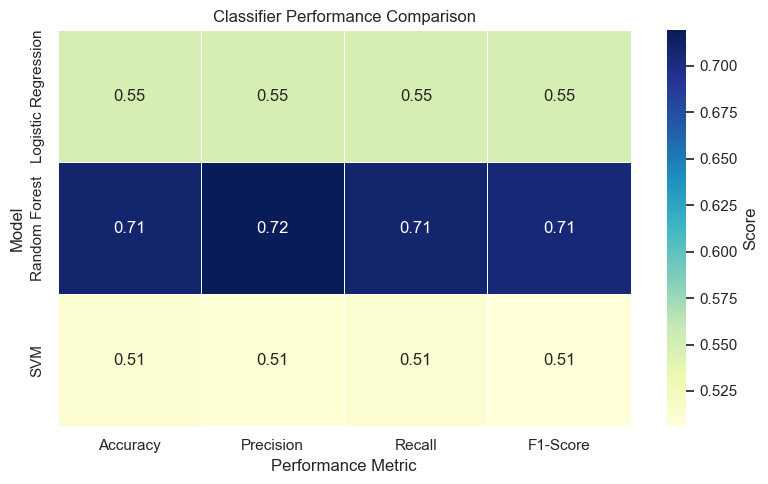

In [4]:
if 'Class' in train_df.columns:
    metrics_list = []
    metrics_list.append(get_metrics(y_train, log_reg.predict(X_train_scaled), 'Logistic Regression'))
    metrics_list.append(get_metrics(y_train, rf.predict(X_train_scaled), 'Random Forest'))
    metrics_list.append(get_metrics(y_train, svm.predict(X_train_scaled), 'SVM'))

    df_perf = pd.DataFrame(metrics_list)
    df_perf.set_index('Model', inplace=True)

    #Heatmap
    plt.figure(figsize=(8, 5))
    sns.set(style="whitegrid")
    sns.heatmap(df_perf, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Score'})
    plt.title("Classifier Performance Comparison")
    plt.ylabel("Model")
    plt.xlabel("Performance Metric")
    plt.tight_layout()
    plt.show()

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Flow_Duration', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Std',
       'Flow_IAT_Max', 'Fwd_IAT_Total', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Bwd_IAT_Total', 'Bwd_IAT_Max', 'Bwd_Packets/s', 'Min_Packet_Length',
       'URG_Flag_Count', 'Down/Up_Ratio', 'Active_Mean', 'Active_Max',
       'Active_Min', 'Idle_Mean', 'Idle_Std', 'Idle_Max', 'Idle_Min'],
      dtype='object')


In [6]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

      Benign       0.54      0.53      0.53     13785
      Trojan       0.56      0.56      0.56     14415

    accuracy                           0.55     28200
   macro avg       0.55      0.55      0.55     28200
weighted avg       0.55      0.55      0.55     28200



In [7]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

      Benign       0.71      0.75      0.73     13785
      Trojan       0.75      0.71      0.73     14415

    accuracy                           0.73     28200
   macro avg       0.73      0.73      0.73     28200
weighted avg       0.73      0.73      0.73     28200



In [9]:
print("Support Vector Machine")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine
              precision    recall  f1-score   support

      Benign       0.50      0.40      0.44     13785
      Trojan       0.52      0.62      0.56     14415

    accuracy                           0.51     28200
   macro avg       0.51      0.51      0.50     28200
weighted avg       0.51      0.51      0.50     28200

